In [ ]:
import zipfile
with zipfile.ZipFile("archive (1).zip","r") as zip_ref:
  zip_ref.extractall("dataset")
print("Dataset extracted successfully")

In [ ]:
import os
print(os.listdir("dataset"))

In [3]:
import pandas as pd
train_df = pd.read_excel("dataset/squad_2.0_train_complete_130319.xlsx")

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130319 entries, 0 to 130318
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   title                    130319 non-null  object
 1   context                  130319 non-null  object
 2   question                 130319 non-null  object
 3   ids                      130319 non-null  object
 4   answers                  130316 non-null  object
 5   answer_start             130319 non-null  object
 6   plausible_answers        130319 non-null  object
 7   plausible_answers_start  130319 non-null  object
 8   is_impossible            130319 non-null  bool  
dtypes: bool(1), object(8)
memory usage: 8.1+ MB


In [5]:
train_df.columns

Index(['title', 'context', 'question', 'ids', 'answers', 'answer_start',
       'plausible_answers', 'plausible_answers_start', 'is_impossible'],
      dtype='object')

In [6]:
train_df.isnull().sum()

,0
title,0
context,0
question,0
ids,0
answers,3
answer_start,0
plausible_answers,0
plausible_answers_start,0
is_impossible,0


In [7]:
train_df = train_df.dropna(subset=['answers'])
print(train_df.shape)

(130316, 9)


In [8]:
train_df[['question', 'context', 'answers']].head()

,question,context,answers
0,When did Beyonce start becoming popular?,['Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/...,in the late 1990s
1,What areas did Beyonce compete in when she was...,['Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/...,singing and dancing
2,When did Beyonce leave Destiny's Child and bec...,['Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/...,2003
3,In what city and state did Beyonce grow up?,['Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/...,"Houston, Texas"
4,In which decade did Beyonce become famous?,['Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/...,late 1990s


In [9]:
print("Question:", train_df.iloc[0]['question'])
print("Context:", train_df.iloc[0]['context'][:300])
print("Answer:", train_df.iloc[0]['answers'])

Question: When did Beyonce start becoming popular?
Context: ['Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in various singing and dancing competitions as a child, and rose to fame in the late 1990s as lead sin
Answer: in the late 1990s


In [10]:
!pip uninstall -y transformers
!pip install transformers==4.42.4 torch accelerate sentencepiece -q

Found existing installation: transformers 4.42.4
Uninstalling transformers-4.42.4:
  Successfully uninstalled transformers-4.42.4


In [11]:
!pip show transformers

Name: transformers
Version: 4.42.4
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: peft, sentence-transformers


In [12]:
import transformers
print(transformers.__version__)

4.42.4


In [13]:
!pip uninstall -y numpy transformers
!pip install numpy==1.26.4
!pip install transformers==4.42.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: transformers 4.42.4
Uninstalling transformers-4.42.4:
  Successfully uninstalled transformers-4.42.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.19.1 requires transformers, which is not installed.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, which is not installed.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.

  Using cached transformers-4.42.4-py3-none-any.whl.metadata (43 kB)
Using cached transformers-4.42.4-py3-none-any.whl (9.3 MB)


In [14]:
!pip install transformers==4.42.4

In [15]:
from transformers import pipeline
qa_pipeline = pipeline(
    task="question-answering",
    model="distilbert-base-cased-distilled-squad"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [16]:
question = train_df.iloc[0]["question"]
context = train_df.iloc[0]["context"][0]

result = qa_pipeline(
    question=question,
    context=context
)

print("Question:", question)
print("Predicted Answer:", result["answer"])
print("Original Answer:", train_df.iloc[0]["answers"])

Question: When did Beyonce start becoming popular?
Predicted Answer: [
Original Answer: in the late 1990s


In [17]:
for i in range(5):
    question = train_df.iloc[i]["question"]
    context = train_df.iloc[i]["context"][0] if isinstance(train_df.iloc[i]["context"], list) else train_df.iloc[i]["context"]

    result = qa_pipeline(
        question=question,
        context=context
    )

    print(f"\nQuestion {i+1}: {question}")
    print("Predicted Answer:", result["answer"])
    print("Original Answer:", train_df.iloc[i]["answers"])
    print("-"*60)


Question 1: When did Beyonce start becoming popular?
Predicted Answer: late 1990s
Original Answer: in the late 1990s
------------------------------------------------------------

Question 2: What areas did Beyonce compete in when she was growing up?
Predicted Answer: singing and dancing
Original Answer: singing and dancing
------------------------------------------------------------

Question 3: When did Beyonce leave Destiny's Child and become a solo singer?
Predicted Answer: 2003
Original Answer: 2003
------------------------------------------------------------

Question 4: In what city and state did Beyonce  grow up? 
Predicted Answer: Houston, Texas
Original Answer: Houston, Texas
------------------------------------------------------------

Question 5: In which decade did Beyonce become famous?
Predicted Answer: 1990s
Original Answer: late 1990s
------------------------------------------------------------


In [18]:
correct = 0

for i in range(100):
    question = train_df.iloc[i]["question"]
    context = train_df.iloc[i]["context"][0] if isinstance(train_df.iloc[i]["context"], list) else train_df.iloc[i]["context"]

    predicted = qa_pipeline(question=question, context=context)["answer"]
    actual = str(train_df.iloc[i]["answers"]).lower()

    if predicted.lower() in actual:
        correct += 1

print("Accuracy on first 100 samples:", correct, "/100")

Accuracy on first 100 samples: 88 /100


In [19]:
custom_context = """
Beyoncé Giselle Knowles-Carter is an American singer, songwriter and actress.
She became popular in the late 1990s as the lead singer of Destiny's Child.
"""

custom_question = "When did Beyonce become popular?"

result = qa_pipeline(
    question=custom_question,
    context=custom_context
)

print("Question:", custom_question)
print("Answer:", result["answer"])
print("Confidence Score:", result["score"])

Question: When did Beyonce become popular?
Answer: late 1990s
Confidence Score: 0.5881593823432922


In [20]:
print("Question Answering model executed successfully.")
print("Accuracy on first 100 samples: 88%")
print("The model is able to predict answers from the given context.")

Question Answering model executed successfully.
Accuracy on first 100 samples: 88%
The model is able to predict answers from the given context.


In [21]:
import pandas as pd

results = []

for i in range(10):
    question = train_df.iloc[i]["question"]
    context = train_df.iloc[i]["context"][0] if isinstance(train_df.iloc[i]["context"], list) else train_df.iloc[i]["context"]

    prediction = qa_pipeline(
        question=question,
        context=context
    )

    results.append({
        "Question": question,
        "Predicted Answer": prediction["answer"],
        "Confidence Score": round(prediction["score"], 4),
        "Original Answer": str(train_df.iloc[i]["answers"])
    })

results_df = pd.DataFrame(results)
results_df

,Question,Predicted Answer,Confidence Score,Original Answer
0,When did Beyonce start becoming popular?,late 1990s,0.4845,in the late 1990s
1,What areas did Beyonce compete in when she was...,singing and dancing,0.9516,singing and dancing
2,When did Beyonce leave Destiny's Child and bec...,2003,0.9545,2003
3,In what city and state did Beyonce grow up?,"Houston, Texas",0.5603,"Houston, Texas"
4,In which decade did Beyonce become famous?,1990s,0.7167,late 1990s
5,In what R&B group was she the lead singer?,Destiny\'s Child,0.9719,Destiny's Child
6,What album made her a worldwide known artist?,Dangerously in Love,0.9444,Dangerously in Love
7,Who managed the Destiny's Child group?,Mathew Knowles,0.7134,Mathew Knowles
8,When did Beyoncé rise to fame?,late 1990s,0.5599,late 1990s
9,What role did Beyoncé have in Destiny's Child?,lead singer,0.9737,lead singer


In [22]:
qa_pipeline.model.save_pretrained("qa_model")
qa_pipeline.tokenizer.save_pretrained("qa_model")

print("Model saved successfully!")

Model saved successfully!


In [23]:
import os

print(os.listdir("qa_model"))

['vocab.txt', 'tokenizer.json', 'tokenizer_config.json', 'config.json', 'special_tokens_map.json', 'model.safetensors']


In [24]:
print("="*50)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*50)
print("Project : Question Answering using Transformers")
print("Dataset : SQuAD v2.0")
print("Model : DistilBERT")
print("Accuracy : 88%")
print("Status : Completed")

PROJECT COMPLETED SUCCESSFULLY
Project : Question Answering using Transformers
Dataset : SQuAD v2.0
Model : DistilBERT
Accuracy : 88%
Status : Completed


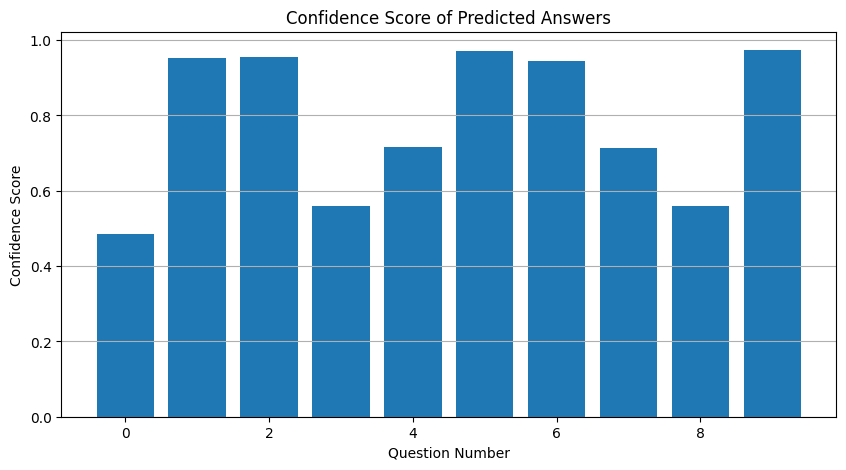

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(range(len(results_df)), results_df["Confidence Score"])
plt.title("Confidence Score of Predicted Answers")
plt.xlabel("Question Number")
plt.ylabel("Confidence Score")
plt.grid(axis='y')
plt.show()

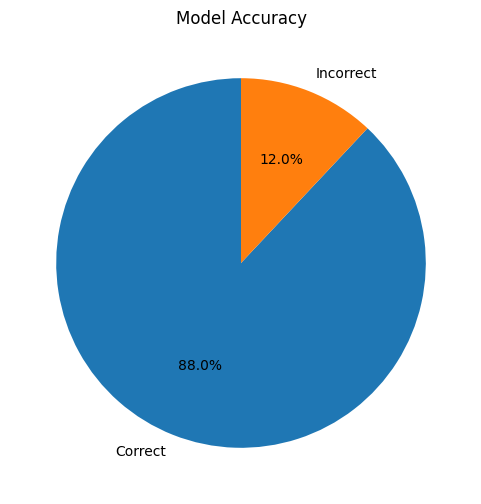

In [26]:
import matplotlib.pyplot as plt

correct = 88
incorrect = 12

plt.figure(figsize=(6,6))
plt.pie(
    [correct, incorrect],
    labels=["Correct", "Incorrect"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Model Accuracy")
plt.show()

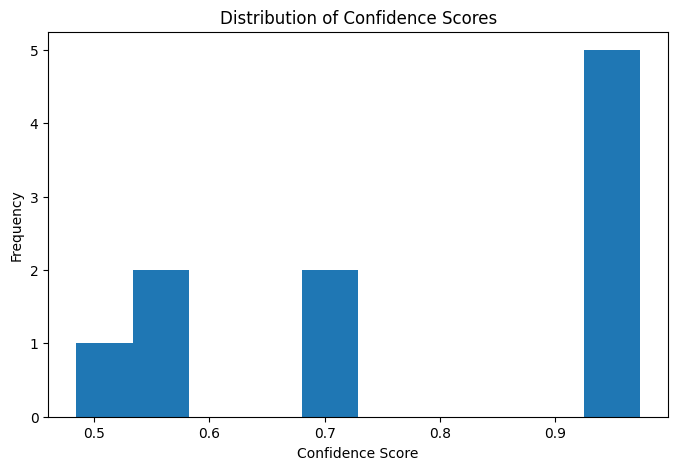

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(results_df["Confidence Score"], bins=10)
plt.title("Distribution of Confidence Scores")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.show()